## Linear Regression Analysis

By Naomi Ortega

This notebook contains analysis of the factors influencing salary in AI roles using linear regression.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
import scipy.stats as stats

In [3]:
data = pd.read_csv('ai_jobs_market_2025_2026.csv')

#Create log salary- Since annual salary is skewed, we will use the log of annual salary.
data['log_salary'] = np.log(data['annual_salary_usd'])
data.head()


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier,log_salary
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k),12.384219
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k),12.019743
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k),12.793859
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k),11.989160
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k),12.553202


In [ ]:
data.columns

Index(['job_id', 'job_title', 'job_category', 'experience_level',
       'years_of_experience', 'education_required', 'annual_salary_usd',
       'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work',
       'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct',
       'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10',
       'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly',
       'is_llm_role', 'salary_tier', 'log_salary'],
      dtype='str')

## Linear Regression Model

We will use multivariate linear regression to see which variables have an effect on salary.  

### Variable selection

We want to select the variables that are relevant for predicting annual salary. We will use regularization using elastic net penalty for variable selection.


First, before putting the data through regularization, we create a new dataframe, which contains the response variable `log_salary` and only the subsection of the variables that are possible to use as covariates to predict log salary.

The changes from the original dataset `data` to the new dataframe `subdata` are
- Drop `job_id`
- Drop `required_skills` because it has too many unique values for feasible use in linear regression
- Drop the response variable `annual_salary_usd` (the response variable is now contained in `log_salary`)
- Drop `is_senior` because it is duplicative (and multicollinear) of the experience_level variable which creates dummy variables for each experience level in the regression model.
- Drop `is_remote_friendly` because it is duplicative of `remote_work` and therefore multicollinear
- Drop the **salary-related** variables: `salary_min_usd, salary_max_usd, ai_salary_premium_pct, salary_tier`
- Drop `posting_month` and `posting_year` since we will not be considering the recency of the posting as a predictor of salary


In [4]:
subdata = data.drop(columns = ['job_id', 'required_skills','annual_salary_usd', 'is_senior', 'is_remote_friendly', 'salary_min_usd','salary_max_usd','ai_salary_premium_pct','salary_tier', 'posting_month', 'posting_year'])
subdata.head()

,job_title,job_category,experience_level,years_of_experience,education_required,city,country,remote_work,company_size,industry,demand_score,demand_growth_yoy_pct,benefits_score_10,is_llm_role,log_salary
0,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,Boston,USA,On-site,Startup (1-50),Finance,96,16.9,6.8,1,12.384219
1,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,London,UK,Hybrid,Enterprise (5000+),Finance,82,11.6,6.2,1,12.019743
2,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,98,42.7,7.7,1,12.793859
3,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,Singapore,Singapore,Fully Remote,SME (51-500),Technology,88,6.7,9.5,0,11.989160
4,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,85,17.3,8.9,0,12.553202


In [4]:
#Now the variables contained in subdata are:
subdata.columns

Index(['job_title', 'job_category', 'experience_level', 'years_of_experience',
       'education_required', 'city', 'country', 'remote_work', 'company_size',
       'industry', 'demand_score', 'demand_growth_yoy_pct',
       'benefits_score_10', 'is_llm_role', 'log_salary'],
      dtype='str')

### Variable Selection with Regularization
Now, we preform variable selection using regularization with the LASSO penalty. We use LASSO for its more extreme selection, because some of the variables have many categories, such as job title, job category, city, and country. We want to distinguish the important groups more definitely so that we can interpret clearly which variables and categories within variables are informative for predicting salary.

In [5]:
full_model_formula = 'log_salary ~ ' + ' + '.join([c for c in subdata.columns if c != 'log_salary'])
full_model_formula

'log_salary ~ job_title + job_category + experience_level + years_of_experience + education_required + city + country + remote_work + company_size + industry + demand_score + demand_growth_yoy_pct + benefits_score_10 + is_llm_role'

Hyperparameter selection- optimal regularization strength

In [9]:
## hyperparameter selection for regularization parameter

from sklearn.model_selection import train_test_split
train, test = train_test_split(subdata, test_size = 0.25, random_state = 0)
train.shape, test.shape

def cv_error(alpha, l1wt, train, test):
    model = smf.ols(full_model_formula, data=train).\
                fit_regularized(method='elastic_net', alpha=alpha, L1_wt=l1wt)
    yhat_test = model.predict(test)
    error = np.sum((test['log_salary'] - yhat_test) ** 2)
    return error


l1wt = 1.0 #specifying L1 weight as 1.0 indicates fully LASSO penalty
alphas = np.linspace(1e-3, 0.5, 200)
cv_errors = np.zeros_like(alphas)

for (i, alpha) in enumerate(alphas):
    cv_errors[i] = cv_error(alpha, l1wt, train, test)

0 0.001
Optimal alpha: 0.001, CV Error: 6.0152654356005115


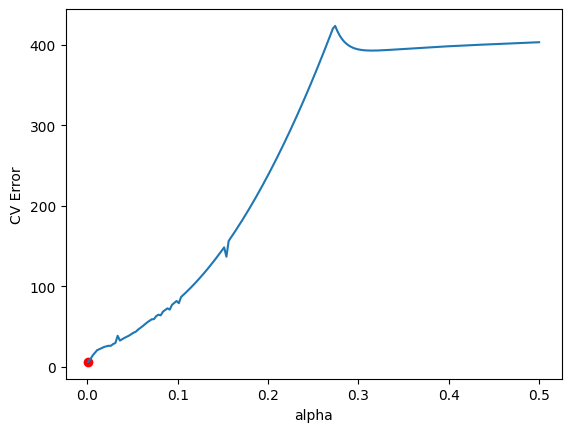

In [10]:


plt.plot(alphas, cv_errors)
print(np.argmin(cv_errors), alphas[np.argmin(cv_errors)])

print(f'Optimal alpha: {alphas[np.argmin(cv_errors)]}, CV Error: {cv_errors[np.argmin(cv_errors)]}')
plt.scatter(alphas[np.argmin(cv_errors)], cv_errors[np.argmin(cv_errors)], color='red')
plt.xlabel('alpha')
plt.ylabel('CV Error');

Using the optimal alpha obtained through cross-validation, apply the elastic net shrinkage method to obtain the useful covariates.

In [11]:
#Fit the model with the optimal alpha
lasso_fit = smf.ols(full_model_formula, data=subdata).\
                fit_regularized(method='elastic_net', alpha=alphas[np.argmin(cv_errors)], L1_wt=l1wt)

### Results: Selected Variables

Below are the selected variables with non zero coefficients.

In [13]:
params_df = pd.DataFrame({
    'variable': lasso_fit.params[lasso_fit.params != 0].index,
    'coefficient': lasso_fit.params[lasso_fit.params != 0].values}
)

#coefficients
params_df

,variable,coefficient
0,Intercept,12.029493
1,job_title[T.AI Business Analyst],-0.326527
2,job_title[T.AI Compliance Manager],-0.048183
3,job_title[T.AI Engineer],-0.167419
4,job_title[T.AI Infrastructure Eng],0.007901
5,job_title[T.AI Solutions Architect],0.238844
6,job_title[T.Computer Vision Engineer],0.031853
7,job_title[T.Data Engineer (AI)],-0.077593
8,job_title[T.Data Scientist],-0.130845
9,job_title[T.LLM Engineer],0.038100


Findings: Selected

* At least 1 of the categories has a nonzero coefficient for the covariates `job_title`, `job_category`, `experience_level`, `education_required`, `city`, `country`, `company_size`, `demand_score`, `demand_growth_yoy_pct`, `benefits_score_10`, `is_llm_role`

* Netherlands and USA were the only meaningul countries. 
* In the case of job category, only governance is significant.

### Non Selected variables

In [15]:
#looking at the coefficients that were shrunk to 0
lasso_fit.params[lasso_fit.params == 0]

job_title[T.AI Ethics Officer]         0.0
job_title[T.AI Product Manager]        0.0
job_title[T.AI Research Scientist]     0.0
job_title[T.AI Security Engineer]      0.0
job_title[T.Deep Learning Engineer]    0.0
job_title[T.Generative AI Engineer]    0.0
job_title[T.ML Engineer]               0.0
job_title[T.MLOps Engineer]            0.0
job_title[T.RAG Engineer]              0.0
job_title[T.Senior Data Scientist]     0.0
job_category[T.Architecture]           0.0
job_category[T.Business]               0.0
job_category[T.Data Engineering]       0.0
job_category[T.Data Science]           0.0
job_category[T.Infrastructure]         0.0
job_category[T.ML Operations]          0.0
job_category[T.Product]                0.0
job_category[T.Research]               0.0
job_category[T.Robotics]               0.0
job_category[T.Security]               0.0
education_required[T.Bachelor's]       0.0
education_required[T.Master's]         0.0
city[T.Austin]                         0.0
city[T.Bost

Findings: Nonselected (variables with 0 coefficients)
* `industry` had no effect
* `remote_work` had no effect

Within variables:
* Many of job roles, job categories, countries, and cities, and education levels had no significant effect. However, for any categories where not all of their categories are 0, we include them in our model, because it is indicative that the categories do influence salary, at least at some level.

### Nonzero but small

Findings: Nonzero but little effect
* `years_of_experience`, `demand_score`, `demand_growth_yoy_pct`, and `benefits_score_10` had nonzero but very small coefficients below 0.001, showing they had very little effect. For our analysis, we will not include them.

------------------------------------

## Final model: significant variables

As a result of using variable selection with elastic net to determine the variables that have an effect on annual salary of AI job roles, our final model for our main analysis using multivariate linear regression includes the following variables:

* `job_title`- Role title
* `job_category` - Role category: (Data Science, AI Engineering, etc.)
* `experience_level` - Entry, Mid, Senior, or Lead
* `education_required` - Minimum required education level
* `city` - City location of job
* `country` - Country location of job
* `company_size` - Startup, SME, Mid-size, Enterprise, Big Tech
* `is_llm_role` - binary variable, 1 for an LLM role


But we know that city and country are not independent, so we will only use city or country in the model.

## Fitting the linear model

### Choosing Reference categories

In [7]:
##job category 

subdata.groupby('job_category')['log_salary'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2)

,count,mean,median
job_category,,,
Architecture,52,12.40,12.38
AI Engineering,736,12.19,12.18
Infrastructure,55,12.18,12.19
Security,50,12.17,12.18
ML Operations,51,12.15,12.15
Product,70,12.14,12.13
Research,50,12.11,12.12
Data Science,127,12.09,12.00
Data Engineering,51,12.04,11.98


Choose `AI Engineering` to be the reference category for job category in linear regression because it is most representative of the data. It is by far the most dominant category with 736 observations, so the interpretations of other category coefficients will be seen in relation to the most popular AI role in the posting.

In [8]:
#Job title
subdata.groupby('job_title')['log_salary'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2)

,count,mean,median
job_title,,,
AI Solutions Architect,52,12.40,12.38
Senior ML Engineer,64,12.39,12.33
LLM Engineer,75,12.35,12.35
AI Agent Developer,57,12.28,12.25
Multimodal AI Engineer,67,12.27,12.25
RAG Engineer,53,12.24,12.28
NLP Engineer,55,12.21,12.10
Computer Vision Engineer,46,12.21,12.21
Generative AI Engineer,71,12.19,12.08


Choose `ML Engineer` for the reference category for job title, since all titles are pretty evenly represented, and ML Engineer is a well-known title that is in the middle of the titles for mean salary. 

In [9]:
#city
subdata.groupby('city')['log_salary'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2)

,count,mean,median
city,,,
New York,67,12.39,12.40
San Francisco,92,12.35,12.36
Seattle,69,12.30,12.31
Remote,82,12.27,12.31
Boston,70,12.25,12.24
Chicago,77,12.24,12.27
Los Angeles,63,12.22,12.25
Austin,77,12.20,12.19
Dubai,62,12.12,12.14


`London` can be the reference category for city, since it is the second most represented city in the data, it is well-known, and it is about in the middle of the log-scale at a mean of 12.05.

In [19]:
final_vars = ['job_title','job_category','experience_level','education_required','city','company_size', 'is_llm_role']


final_formula = '''log_salary ~ C(job_title, Treatment("ML Engineer")) + C(job_category, Treatment("AI Engineering")) + C(experience_level, Treatment("Entry (0-2 yrs)")) + C(education_required, Treatment("Bachelor's")) + C(city, Treatment("London")) + C(company_size, Treatment("Mid-size (501-5000)")) + is_llm_role'''
final_model = smf.ols(final_formula, data = subdata).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     192.5
Date:                Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:49:19   Log-Likelihood:                 1091.0
No. Observations:                1500   AIC:                            -2072.
Df Residuals:                    1445   BIC:                            -1780.
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                                                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [52]:
subdata.experience_level.value_counts()

experience_level
Entry (0-2 yrs)     385
Lead (10+ yrs)      381
Mid (3-5 yrs)       370
Senior (6-9 yrs)    364
Name: count, dtype: int64

In [44]:
subdata.company_size.value_counts()

company_size
Mid-size (501-5000)    312
SME (51-500)           300
Big Tech (FAANG+)      299
Enterprise (5000+)     297
Startup (1-50)         292
Name: count, dtype: int64

### Assessing the Assumptions of the Model and Influential points

Checking for Influential Points: Cook's Distance

In [31]:
influence = final_model.get_influence()
cooks_d = influence.cooks_distance[0]

max_cook_position = np.argmax(cooks_d)
max_cook_index = subdata.index[max_cook_position]

print('Largest Cook distance row index:', max_cook_index)
print('Cook distance:', cooks_d[max_cook_position])
print('Suggested cutoff 4/n:', 4 / len(subdata))


Largest Cook distance row index: 1268
Cook distance: 0.016969809449047062
Suggested cutoff 4/n: 0.0026666666666666666


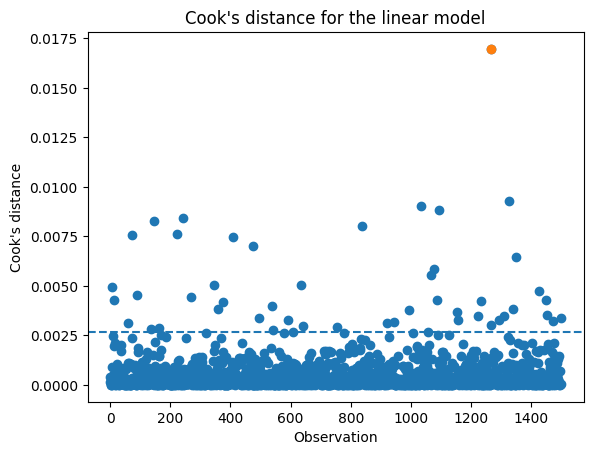

In [25]:
plt.scatter(range(len(cooks_d)), cooks_d)
plt.axhline(4 / len(subdata), linestyle='--')
plt.scatter(max_cook_position, cooks_d[max_cook_position])
plt.xlabel('Observation')
plt.ylabel("Cook's distance")
plt.title("Cook's distance for the linear model")
plt.show()

In [73]:
data.annual_salary_usd.mean()

np.float64(194892.0)

Look at the influential point

In [32]:
data.loc[[max_cook_index], ['job_id', 'job_title', 'job_category', 'experience_level',
                            'years_of_experience', 'education_required',
                            'annual_salary_usd', 'city', 'country', 'company_size']]

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,city,country,company_size
1268,AIJOB1269,Senior Data Scientist,Data Science,Entry (0-2 yrs),7,Associate's,157000.0,Beijing,China,Startup (1-50)


The influential point is a Senior Data Scientist role. This point may possibly be miscategorized in experience level, since it is listed as an entry level position, yet it has "senior" in the title and requires 7 years of experience. Since this point has a very high influence on the coefficients of the model and the categorization is conflicting, we remove the row and refit the model.

In [35]:

subdata_no_influential = subdata.drop(index=max_cook_index)

final_model_no_influential = smf.ols(final_formula, data=subdata_no_influential).fit()
print(final_model_no_influential.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     221.7
Date:                Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:20:36   Log-Likelihood:                 1184.1
No. Observations:                1499   AIC:                            -2258.
Df Residuals:                    1444   BIC:                            -1966.
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                                                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

### Checking OLS Assumptions

In [49]:
fitted_values = final_model_no_influential.fittedvalues
residuals = final_model_no_influential.resid

def standardize(X):
    return (X - X.mean()) / X.std()

standardized_resid = standardize(residuals)

Linearity- all of the variables in our model are categorical, so linearity does not apply.

Independence

<Axes: >

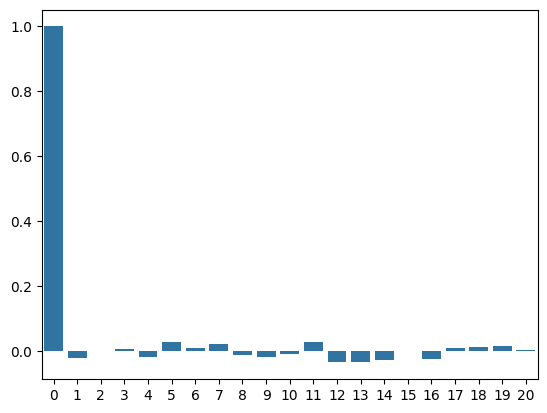

In [71]:
#Autocorrelation function
from statsmodels.tsa.stattools import acf

sns.barplot(acf(residuals, nlags = 20))


In [72]:
#Ljung-Box test: tests if autocorrelation is significantly different from 0
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(residuals, lags=20, return_df=True)
ljung_box

,lb_stat,lb_pvalue
1,0.739723,0.389749
2,0.740041,0.690720
3,0.789895,0.851882
4,1.276484,0.865353
5,2.387872,0.793279
6,2.528489,0.865266
7,3.303270,0.855602
8,3.482549,0.900540
9,3.925466,0.916249
10,4.099165,0.942763


The ACF function is close to 0 for all lags 1-20, and the pvalue of the Ljung Box test is not significant for any lags. The independence assumption is met.

Normality

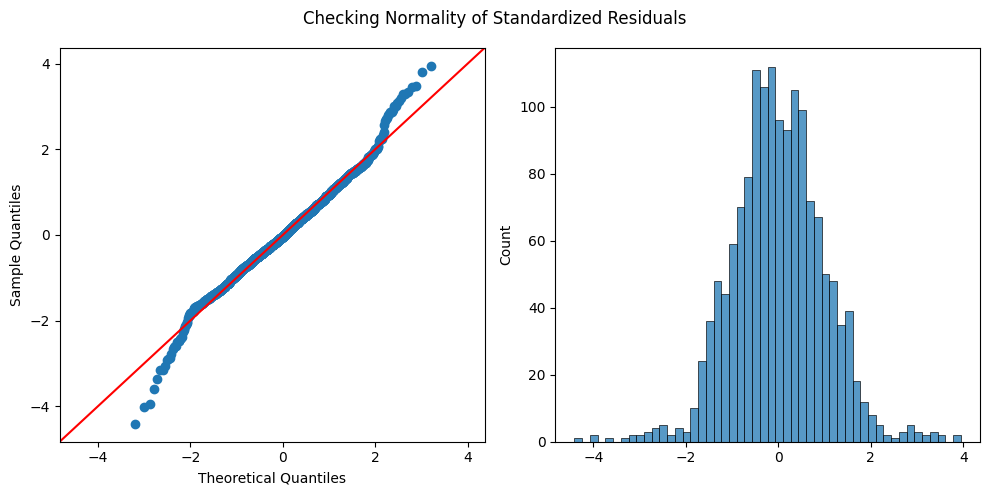

In [68]:
## QQ plot and histogram of standardized residuals

fig, axes = plt.subplots(1, 2, figsize = (10,5))
sm.qqplot(standardized_resid, line = '45', ax = axes[0])
sns.histplot(standardized_resid, bins = 50)

fig.suptitle('Checking Normality of Standardized Residuals')
plt.tight_layout()
plt.show()

In [51]:
#2. Shapiro Wilk Test
stats.shapiro(standardized_resid)

ShapiroResult(statistic=np.float64(0.9888587267852506), pvalue=np.float64(2.693989632285126e-09))

The QQ plot of the standardized residuals shows downward curvature at the bottom and upward curvature at the top, indicative of heavy tails. The histogram supports this, with a lot of residuals between the 2 to 4 and -4 to -2 range. The heavy tails make the residuals appear nonnormal.

The Shapiro Wilk test produces a small pvalue, 2.69e-9, rejecting the null of normality.

So the normality assumption is not met for our model.

Homoscedasticity

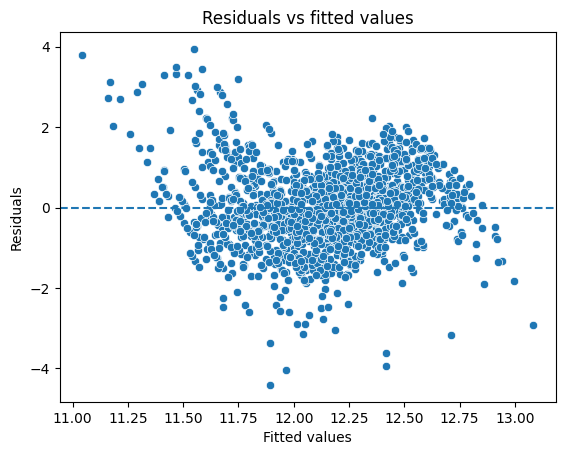

In [70]:
sns.scatterplot(x = fitted_values, y = standardized_resid)
plt.axhline(0, linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs fitted values')
plt.show()

In [44]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, final_model_no_influential.model.exog)
print('Breusch-Pagan p-value:', bp_test[1])
print('Jarque-Bera test:', stats.jarque_bera(residuals))

Breusch-Pagan p-value: 1.3529720217266777e-57
Jarque-Bera test: SignificanceResult(statistic=np.float64(94.83600566200042), pvalue=np.float64(2.5504864912969894e-21))


The standardized residuals appear randomly scattered, although to the top left, the cluster of residuals looks unlike the rest. The Breuch-Pagan test for homoscedasticity gives a small pvalue, 1.35e-57, rejecting homoscedasticity and accepting the alternative of heteroscedasticity, so the homoscedasticity assumption is not met.

## Interpretations:


In [ ]:
#visualizations